In [13]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 
 

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Step 1: Load dataset
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)

df = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)

print("Shape:", df.shape)
print(df.head())


Shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  


In [15]:
# Identify categorical & numerical columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols += ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]  # known categoricals

numerical_cols = [col for col in df.columns if col not in categorical_cols + ["num"]]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ])


Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']


In [ ]:
X = df.drop("num", axis=1)
y = df["num"].apply(lambda v: 0 if v == 0 else 1)  # Binary classification: 0 = no disease, 1 = disease

X_processed = preprocessor.fit_transform(X)

print("Processed feature shape:", X_processed.shape)


Processed feature shape: (303, 25)


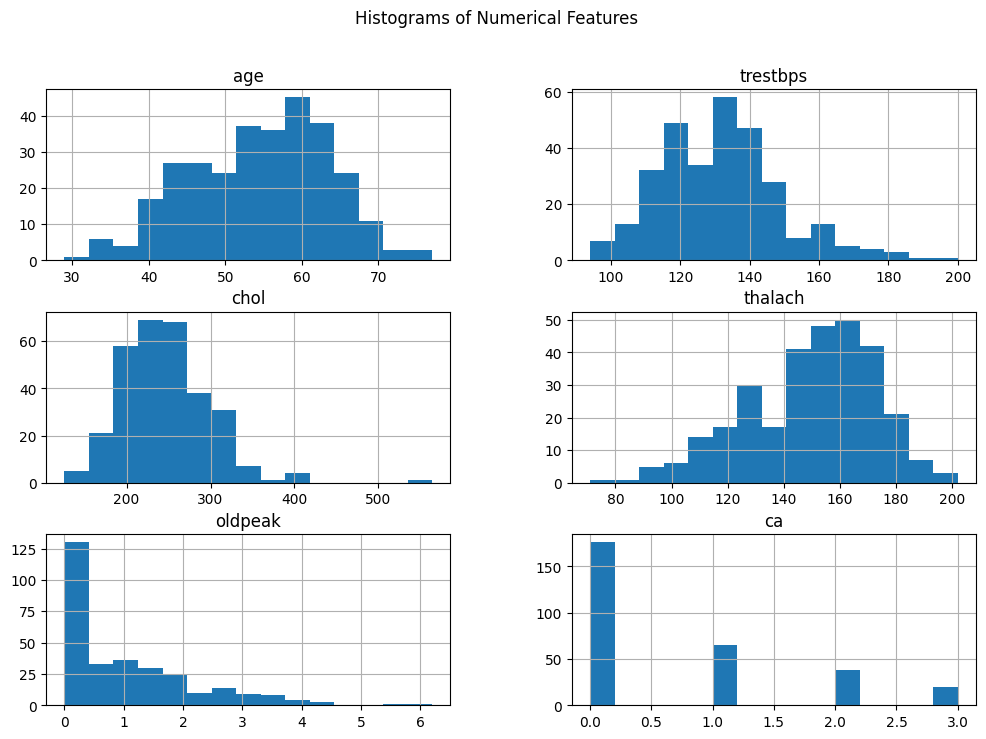

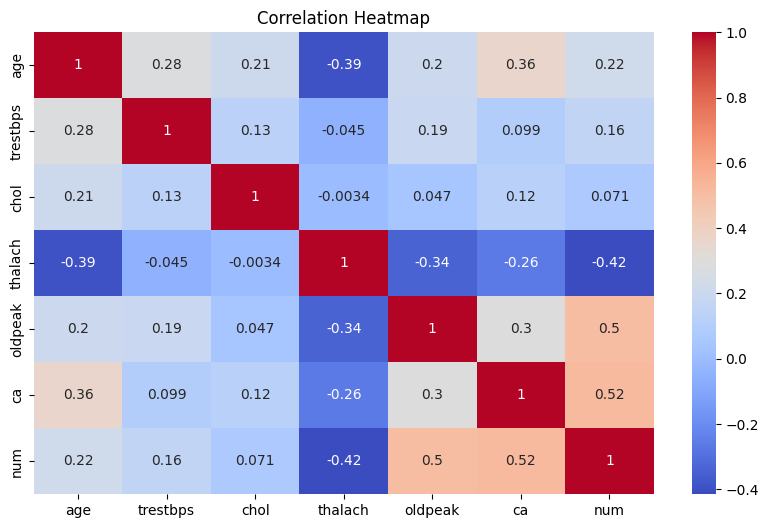

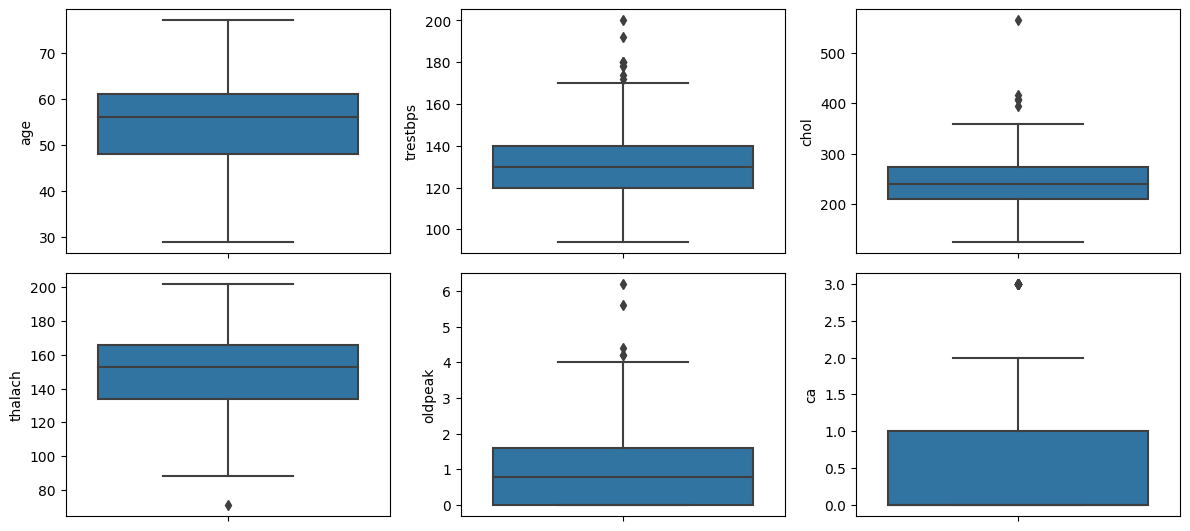

In [17]:
# 1. Histograms of numerical features
df[numerical_cols].hist(bins=15, figsize=(12, 8))
plt.suptitle("Histograms of Numerical Features")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols + ["num"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 3. Boxplots for outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, y=col)
plt.tight_layout()
plt.show()


In [20]:
processed_columns = preprocessor.get_feature_names_out()  # works with ColumnTransformer
X_processed_df = pd.DataFrame(X_processed, columns=processed_columns)

# Add target column
final_df = pd.concat([X_processed_df, y.reset_index(drop=True)], axis=1)

# Save to CSV
final_df.to_csv("../data/cleaned_heart_disease.csv", index=False)

print("✅ Preprocessed data saved to data/cleaned_heart_disease.csv")

✅ Preprocessed data saved to data/cleaned_heart_disease.csv
